In [ ]:
import pandas as pd
import numpy as np
from lightgbm import LGBMRegressor

# 1. Load the dataset
file_path = '../data/training_data_v6_no0min_trial.csv'
df = pd.read_csv(file_path)

def generate_fpl_windows(df, window_size=6):
    train_data = []
    
    # Mapping to exact column names from debug output
    uuid_col = 'Player UUID'
    season_col = 'season'
    gw_col = 'Gameweek'
    points_col = 'Total Points'
    pos_col = 'Position'

    # Sort to ensure chronological order per player
    df = df.sort_values([uuid_col, season_col, gw_col])
    
    # Group by UUID so windows stay within a single player's history
    for pid, group in df.groupby(uuid_col):
        points = group[points_col].values
        
        # Check if the player has enough data points
        if len(points) <= window_size:
            continue
            
        # Get the position (it's the same for all rows of this player)
        position = group[pos_col].iloc[0] 
        
        for i in range(len(points) - window_size):
            window = points[i : i + window_size]
            target = points[i + window_size]
            
            # Rule: Skip windows where the player scored 0 points for 6 weeks straight
            if np.all(window == 0):
                continue
                
            # Create a row: [lag_6, lag_5, lag_4, lag_3, lag_2, lag_1, position, target]
            row = list(window) + [position, target]
            train_data.append(row)
            
    # Define columns: lag_6 is oldest, lag_1 is most recent
    columns = [f'lag_{i}' for i in range(window_size, 0, -1)] + ['position', 'target']
    return pd.DataFrame(train_data, columns=columns)

# Execute the transformation
windowed_df = generate_fpl_windows(df)

# Convert position to 'category' for LightGBM
windowed_df['position'] = windowed_df['position'].astype('category')

# Final check
print(f"Dataset created with {windowed_df.shape[0]} rows and {windowed_df.shape[1]} columns.")
windowed_df.head()

Dataset created with 20580 rows and 8 columns.


,lag_6,lag_5,lag_4,lag_3,lag_2,lag_1,position,target
0,1,1,2,2,0,1,MID,1
1,1,2,2,0,1,1,MID,2
2,2,2,0,1,1,2,MID,2
3,2,0,1,1,2,2,MID,2
4,0,1,1,2,2,2,MID,1


In [ ]:
#%pip install pandas numpy lightgbm scikit-learn matplotlib seaborn

  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
  Using cached contourpy-1.3.3-cp313-cp313-win_amd64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached kiwisolver-1.4.9-cp313-cp313-win_amd64.whl.metadata (6.4 kB)
   ---------------------------------------- 0.0/8.0 MB ? eta -:--:--
   ---------------------------------------- 8.0/8.0 MB 45.9 MB/s  0:00:00
   ---------------------------------------- 0.0/8.1 MB ? eta -:--:--
   ---------------------------------------- 8.1/8.1 MB 93.5 MB/s  0:00:00
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)
Using cached contourpy-1.3.3-cp313-cp313-win_amd64.whl (226 kB)
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
   ---------------------------------------- 0.0/2.3 MB ? eta -:--:--
   ---------------------------------------- 2.3/2.3 MB 54.4 MB/s  0:00:00
Using cached kiwisolver-1.4.9-cp313-cp313-win_amd64


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# 1. Prepare X (features) and y (target)
# We drop 'target' for X, and keep 'position' as it is already a category
X = windowed_df.drop(columns=['target'])
y = windowed_df['target']

# 2. Chronological Split
# Since goal is to predict 2026, we'll use the last 15% of the 
# generated windows as our validation set to mimic "recent" performance.
split_index = int(len(windowed_df) * 0.85)

X_train_raw = X.iloc[:split_index]
X_val_raw = X.iloc[split_index:]
y_train = y.iloc[:split_index]
y_val = y.iloc[split_index:]

# 3. Scaling the numeric 'lag' features
# not scale 'position', so it is separated briefly
lag_cols = [c for c in X.columns if 'lag' in c]

scaler = StandardScaler()

# Fit and transform training lags
X_train_scaled = X_train_raw.copy()
X_train_scaled[lag_cols] = scaler.fit_transform(X_train_raw[lag_cols])

# Transform validation lags using the SAME scaler
X_val_scaled = X_val_raw.copy()
X_val_scaled[lag_cols] = scaler.transform(X_val_raw[lag_cols])

print(f"Training set size: {len(X_train_scaled)}")
print(f"Validation set size: {len(X_val_scaled)}")
print("\nFirst few rows of scaled training data:")
X_train_scaled.head()

Training set size: 17493
Validation set size: 3087

First few rows of scaled training data:


,lag_6,lag_5,lag_4,lag_3,lag_2,lag_1,position
0,-0.614551,-0.614249,-0.284432,-0.285614,-0.943225,-0.614697,MID
1,-0.614551,-0.285765,-0.284432,-0.943706,-0.614288,-0.614697,MID
2,-0.285089,-0.285765,-0.943970,-0.614660,-0.614288,-0.285943,MID
3,-0.285089,-0.942734,-0.614201,-0.614660,-0.285350,-0.285943,MID
4,-0.944013,-0.614249,-0.614201,-0.285614,-0.285350,-0.285943,MID


Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[198]	valid_0's l2: 8.21656

--- Model Performance ---
Mean Absolute Error: 2.1026
Root Mean Squared Error: 2.8665


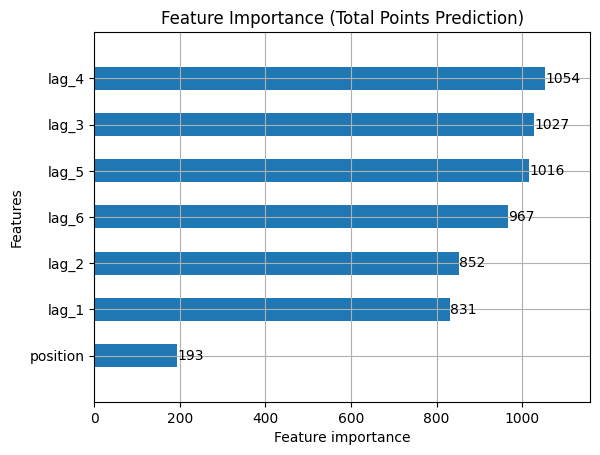

In [ ]:
import lightgbm as lgb
from sklearn.metrics import mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt

# 1. Initialize the LightGBM Regressor
# use of moderate hyperparameters, 'verbosity': -1 keeps the output clean
model = lgb.LGBMRegressor(
    n_estimators=1000,
    learning_rate=0.01,
    max_depth=6,
    num_leaves=31,
    boosting_type='gbdt',
    random_state=42,
    verbosity=-1
)

# 2. Fit the model
# pass the validation set to monitor performance
model.fit(
    X_train_scaled, y_train,
    eval_set=[(X_val_scaled, y_val)],
    categorical_feature=['position'],
    callbacks=[lgb.early_stopping(stopping_rounds=50)]
)

# 3. Evaluation
preds = model.predict(X_val_scaled)
mae = mean_absolute_error(y_val, preds)
rmse = np.sqrt(mean_squared_error(y_val, preds))

print(f"\n--- Model Performance ---")
print(f"Mean Absolute Error: {mae:.4f}")
print(f"Root Mean Squared Error: {rmse:.4f}")

# 4. Feature Importance Plot
lgb.plot_importance(model, height=0.5, title="Feature Importance (Total Points Prediction)")
plt.show()

In [ ]:
# 1. Get the most recent window for each player to predict their NEXT game
latest_windows = []
player_names = [] 

# use of the original 'df' (your training_data_v6...) to get the absolute latest data
for pid, group in df.groupby('Player UUID'):
    # Sort by time to be sure we have the latest
    group = group.sort_values(['season', 'Gameweek'])
    
    if len(group) >= 6:
        # Take the last 6 entries
        last_6_points = group['Total Points'].tail(6).values
        pos = group['Position'].iloc[-1]
        name = group['Web Name'].iloc[-1]
        
        latest_windows.append(list(last_6_points) + [pos])
        player_names.append(name)

# 2. Convert to DataFrame
inference_df_raw = pd.DataFrame(latest_windows, 
                               columns=[f'lag_{i}' for i in range(6, 0, -1)] + ['position'])

# 3. Scale using the scaler from Cell 2
inference_df_scaled = inference_df_raw.copy()
inference_df_scaled[lag_cols] = scaler.transform(inference_df_raw[lag_cols])
inference_df_scaled['position'] = inference_df_scaled['position'].astype('category')

# 4. Generate Predictions
final_preds = model.predict(inference_df_scaled)

# 5. Create the Final Results Table
results = pd.DataFrame({
    'Player': player_names,
    'Predicted_Points': np.round(final_preds, 2)
}).sort_values(by='Predicted_Points', ascending=False)

print("--- Top 10 Predicted Performers for the Next Gameweek ---")
print(results.head(10))

--- Top 10 Predicted Performers for the Next Gameweek ---
       Player  Predicted_Points
295     Olise              6.00
84   Casemiro              5.08
89       Rice              4.64
562   Gabriel              4.63
188    Mateta              4.62
155    Thiago              4.40
223     Keane              4.30
406   G.Jesus              4.29
232  Gündogan              4.26
556  Martinez              4.25


In [ ]:
import joblib
import os
import pandas as pd
import numpy as np
from pathlib import Path

# 1. Setup paths
output_dir = Path('../output')
output_dir.mkdir(parents=True, exist_ok=True)

detailed_results = []

# Define lag columns for scaling (ensure these match training)
lag_cols = [f'lag_{i}' for i in range(6, 0, -1)]

for pid, group in df.groupby('Player UUID'):
    group = group.sort_values(['season', 'Gameweek'])
    
    if len(group) >= 6:
        last_row = group.iloc[-1]
        name = last_row['Web Name']
        current_season = last_row['season'] 
        last_gw = int(last_row['Gameweek'])
        
        # SEASON ROLLOVER LOGIC 
        if last_gw < 38:
            # Still in the same season
            predicted_gw = last_gw + 1
            predicted_season = current_season
        else:
            # Season ended, predict GW 1 of the NEXT season
            predicted_gw = 1
            # Logic to turn "2024-25" -> "2025-26"
            try:
                years = current_season.split('-')
                start_yr = int(years[0]) + 1
                end_yr = int(years[1]) + 1
                predicted_season = f"{start_yr}-{end_yr}"
            except:
                # Fallback if season format is different
                predicted_season = "Next Season"

        # 2. Get features (last 6 games)
        last_6_points = group['Total Points'].tail(6).values
        pos = last_row['Position']
        
        # 3. Scale and Predict
        window_df = pd.DataFrame([list(last_6_points) + [pos]], 
                                columns=lag_cols + ['position'])
        
        # Transform using the scaler from Cell 2
        window_df[lag_cols] = scaler.transform(window_df[lag_cols])
        window_df['position'] = window_df['position'].astype('category')
        
        pred_val = model.predict(window_df)[0]
        
        detailed_results.append({
            'Player UUID': pid,
            'Player Name': name,
            'Season': predicted_season, 
            'Predicted GW': predicted_gw,
            'Predicted Total Points': round(float(pred_val), 2)
        })

# Create DataFrame
final_df = pd.DataFrame(detailed_results).sort_values(by='Predicted Total Points', ascending=False)

# 4. Save Files
csv_path = output_dir / 'lgbm_2026.csv'
model_path = output_dir / 'lgbm_window_model.txt'
scaler_path = output_dir / 'points_scaler.pkl'

final_df.to_csv(csv_path, index=False)
model.booster_.save_model(str(model_path))
joblib.dump(scaler, scaler_path)

print(f"Success! Predictions for {final_df['Season'].iloc[0]} saved to: {csv_path}")
final_df.head()
        



Success! Predictions for 2024-25 saved to: ..\output\lgbm_2026.csv


,Player UUID,Player Name,Season,Predicted GW,Predicted Total Points
295,6bf5d245-90a3-4de0-a7c2-0efafc075bbf,Olise,2024-25,1,6.00
84,22ece02c-4f53-4815-bca1-629854a5f2cd,Casemiro,2025-26,12,5.08
89,24a4a261-c963-4dfd-90e6-3f8a4be8e872,Rice,2025-26,12,4.64
562,d47d25b6-6111-4093-bdd2-f6385cb7f7a3,Gabriel,2025-26,12,4.63
188,47cecb8e-adce-4abe-bdbe-ccc1bfd57a0f,Mateta,2025-26,12,4.62


In [ ]:
# latest season and gameweek 
latest_info = df.sort_values(['season', 'Gameweek']).iloc[-1]
print(f"Latest data in file: {latest_info['season']} | Gameweek: {latest_info['Gameweek']}")
print(f"Therefore, predictions are for the FOLLOWING Gameweek.")

Latest data in file: 2025-26 | Gameweek: 11
Therefore, predictions are for the FOLLOWING Gameweek.


## Notes

* **lags**: the 6 features are the Total Points scored by a player in their 6 most recent games
    * Lag 1: Points from the most recent game
    * Lag 2: Points from the game before that... and so on, back to Lag 6.
* **Scaling**: used the StandardScaler. This subtracts the Mean (average) from every point and divides it by the Standard Deviation.
  the Result: all points are now centered around 0. A value of 1.5 means the player scored significantly higher than average, while -0.8 means they scored lower than average
* **position** became categorical variable 
* **skip rows with only zeros**: np.all(window == 0) checks if every single one of the 6 lags in that specific window is 0.
